In [24]:
using SparseArrays
#using ThreadedSparseArrays
using DifferentialEquations
using Plots
using LaTeXStrings
using Printf

In [2]:
struct DifferentialProblem
    #H0::ThreadedSparseMatrixCSC{ComplexF64, Int, SparseMatrixCSC{ComplexF64, Int}}
    #H1::ThreadedSparseMatrixCSC{ComplexF64, Int, SparseMatrixCSC{ComplexF64, Int}}
    #H2::ThreadedSparseMatrixCSC{ComplexF64, Int, SparseMatrixCSC{ComplexF64, Int}}
    H0::SparseMatrixCSC{ComplexF64, Int}
    H1::SparseMatrixCSC{ComplexF64, Int}
    H2::SparseMatrixCSC{ComplexF64, Int}
    β::Function
    N::Int
    n_max::Int
    #function DifferentialProblem(H0::SparseMatrixCSC{ComplexF64, Int}, H1::SparseMatrixCSC{ComplexF64, Int}, H2::SparseMatrixCSC{ComplexF64, Int}, β::Function, N::Int, n_max::Int)
    #    new(ThreadedSparseMatrixCSC(H0), ThreadedSparseMatrixCSC(H1), ThreadedSparseMatrixCSC(H2), β, N, n_max)
    #end
end

In [3]:
# Define creation and annihilation operators for the Fock basis
function create_annihilation_operators(n_max::Int)
    rows = Int[]
    cols = Int[]
    vals = Float64[]
    
    for n in 1:n_max
        push!(rows, n)
        push!(cols, n+1)
        push!(vals, sqrt(n))
    end
    
    a = sparse(rows, cols, vals, n_max+1, n_max+1)
    a_dag = sparse(cols, rows, vals, n_max+1, n_max+1)
    
    return a, a_dag
end

# Define Pauli matrices
σx = [0 1; 1 0]
σy = [0 -im; im 0]
σz = [1 0; 0 -1]
σ_plus = [0 1; 0 0]
σ_minus = [0 0; 1 0]

function sparse_diag_ones(n::Int)
    return sparse(1:n, 1:n, ones(ComplexF64, n), n, n)
end

function time_independent_hamiltonian(N::Int, n_max::Int, Δcs::Float64, Δ::Float64, g::Float64)
    a, a_dag = create_annihilation_operators(n_max)
    I_fock = sparse_diag_ones(n_max+1)
    I_spin = sparse_diag_ones(2^N)
    H0 = Δcs * kron(a_dag * a, I_spin)

    for j in 1:N
        σz_j = kron(I_fock, kron(sparse_diag_ones(2^(j-1)), kron(σz, sparse_diag_ones(2^(N-j)))))
        H0 += (Δ / 2) * σz_j
    end

    for j in 1:N
        σ_plus_j = kron(sparse_diag_ones(2^(j-1)), kron(σ_plus, sparse_diag_ones(2^(N-j))))
        σ_minus_j = kron(sparse_diag_ones(2^(j-1)), kron(σ_minus, sparse_diag_ones(2^(N-j))))

        H0 += g * (kron(a, σ_plus_j) + kron(a_dag, σ_minus_j))
    end

    return H0
end

function time_dependent_hamiltonian_terms(n_max::Int)
    a, a_dag = create_annihilation_operators(n_max)
    I_fock = sparse(1:n_max, 1:n_max, ones(ComplexF64, n_max), n_max, n_max)
    I_spin = sparse(1:2^N, 1:2^N, ones(ComplexF64, 2^N), 2^N, 2^N)

    H1 = im * kron(a_dag, I_spin) # * beta()
    H2 = -im * kron(a, I_spin) # * conj(beta())

    return H1, H2
end

function full_hamiltonian(N::Int, n_max::Int, Δcs::Float64, Δ::Float64, g::Float64)
    H0 = time_independent_hamiltonian(N, n_max, Δcs, Δ, g)
    H1, H2 = time_dependent_hamiltonian_terms(n_max)
    
    return H0, H1, H2
end

full_hamiltonian (generic function with 1 method)

In [4]:
function combined_index(boson_state::Int, spin_state::Vector{Int}, p::DifferentialProblem)
    n_max, N = p.n_max, p.N
    # Compute the index for the bosonic state
    boson_index = boson_state
    # Compute the index for the spin state
    spin_index = 0
    for (i, s) in enumerate(1 .- spin_state)
        spin_index += s * 2^(N - i)
    end
    # Combine both indices
    index = boson_index * 2^N + spin_index + 1  # +1 for 1-based indexing in Julia
    return index
end

function index_to_state(index::Int, p::DifferentialProblem)
    n_max, N = p.n_max, p.N
    index -= 1  # Adjust for 1-based indexing
    boson_index = div(index, 2^N)
    spin_index = index % 2^N
    
    # Convert spin_index back to binary spin state
    spin_state = zeros(Int, N)
    for i in 1:N
        spin_state[i] = 1 .- (spin_index ÷ 2^(N-i)) % 2
    end
    return boson_index, spin_state
end
# Test 
#combined_index(0, [1,1], p)
#index_to_state(5, p)

index_to_state (generic function with 1 method)

In [5]:
function gen_spin_excitations(num_excitations::Int, p::DifferentialProblem)::Vector{Vector{Int}}
    N = p.N
    function combinations(n::Int, k::Int)::Vector{Vector{Int}}
        if k == 0
            return [Int[]]
        elseif n == 0
            return Vector{Vector{Int}}()
        else
            include_first = combinations(n-1, k-1)
            for v in include_first
                push!(v, n)
            end
            exclude_first = combinations(n-1, k)
            return vcat(include_first, exclude_first)
        end
    end

    indices = combinations(N, num_excitations)
    spin_excitations = Vector{Vector{Int}}()

    for index_set in indices
        spin_state = zeros(Int, N)
        for idx in index_set
            spin_state[idx] = 1
        end
        push!(spin_excitations, spin_state)
    end

    return spin_excitations
end

function combined_indexes(boson_state::Int, spin_states::Vector{Vector{Int}}, p::DifferentialProblem)
    indexes = Int[]
    for s in spin_states
        push!(indexes, combined_index(boson_state, s, p))
    end
    return indexes
end
function combined_indexes(boson_states::Vector{Int}, spin_state::Vector{Int}, p::DifferentialProblem)
    indexes = Int[]
    for b in boson_states
        push!(indexes, combined_index(b, spin_state, p))
    end
    return indexes
end

function spin_state_indexes(spin_state::Vector{Int}, p::DifferentialProblem)
    indexes = Int[]
    for b in 0:n_max
        push!(indexes, combined_index(b, spin_state, p))
    end
    return indexes
end

function gen_spin_excitation_indexes(num_excitations::Int, num_photons::Int, p::DifferentialProblem)
    spin_excitations = gen_spin_excitations(num_excitations, p)
    return combined_indexes(num_photons, spin_excitations, p)
end

function gen_cavity_excitation_indexes(num_photons::Int, p::DifferentialProblem)
    all_indexes::Vector{Int} = []
    N = p.N
    num_indexes = 2^N
    first_index = num_indexes * num_photons + 1
    last_index = num_indexes * (num_photons + 1)
    indexes::Vector{Int} = collect(first_index : last_index)
    return indexes
end

gen_cavity_excitation_indexes (generic function with 1 method)

In [19]:
# functions that creates spin state superposition of n (or single) excitation states with equal weights and zero cavity excitations
function n_excitation_state(n::Int, p::DifferentialProblem; do_sparse::Bool=false)
    n_max, N = p.n_max, p.N
    indexes = zeros(Int, N)
    spin_excitations = gen_spin_excitations(n, p)
    indexes = combined_indexes(0, spin_excitations, p)
    if do_sparse
        ψ = sparsevec(indexes, ones(ComplexF64, N)/sqrt(N), 2^N*(n_max+1))
    else
        ψ = zeros(ComplexF64, 2^N*(n_max+1))
        ψ[indexes] = ones(ComplexF64, N)/sqrt(N)
    end
    return ψ
end
function single_excitation_state(p::DifferentialProblem; do_sparse::Bool=false)
    return n_excitation_state(1, p, do_sparse=do_sparse)
end
function n_excitation_vec(n::Int, p::DifferentialProblem)
    N = p.N
    vec::Vector{Int} = zeros(Int, N)
    for i in 1:n
        vec[i] = 1
    end
    return vec
end

n_excitation_vec (generic function with 1 method)

In [115]:
function solver(phi0, T, p::DifferentialProblem; how_often::Int=10, abstol::Float64=1e-8, reltol::Float64=1e-8)
    start_time = time()
    function progress_callback(integrator)
        # Current simulation time
        current_t = integrator.t
        # Final time (should be set or known beforehand)
        final_T = integrator.sol.prob.tspan[2]
        # Elapsed time
        elapsed_time = time() - start_time
        elapsed_hours, elapsed_remainder = divrem(elapsed_time, 3600)
        elapsed_minutes, elapsed_seconds = divrem(elapsed_remainder, 60)
        # Remaining time estimation
        if current_t > integrator.sol.prob.tspan[1]
            how_many_times = final_T/current_t - 1
            remaining_time = elapsed_time * how_many_times
        else
            remaining_time = NaN
        end
        remaining_hours, remaining_remainder = divrem(remaining_time, 3600)
        remaining_minutes, remaining_seconds = divrem(remaining_remainder, 60)
        # Current iteration number
        iterations = integrator.iter
        # make string of $current_t / $final_T", but with only 2 decimal places
        str_current_t = @sprintf("%.2f", current_t)
        str_final_T = @sprintf("%.2f", final_T)
        # Print the formatted time and iteration info
        println("Elapsed: $(@sprintf("%02d:%02d:%02d", elapsed_hours, elapsed_minutes, trunc(Int, elapsed_seconds)))",
                " | Remaining: $(@sprintf("%02d:%02d:%02d", remaining_hours, remaining_minutes, trunc(Int, remaining_seconds)))",
                " | t = $str_current_t / $str_final_T",
                " | Iteration: $iterations")
    end
    function condition(u, t, integrator)
        iterations = integrator.iter
        if iterations%how_often == 0
            return true
        else
            return false
        end
    end
    
    prob = ODEProblem(timestep_generator!, phi0, (0.0, T), p)
    callback = DiscreteCallback(condition, progress_callback)

    # Solve the problem with the callback
    start_time = time()
    sol = solve(prob, Tsit5(), callback=callback, save_everystep=false, abstol=abstol, reltol=reltol)
    return sol
end

solver (generic function with 2 methods)

In [134]:
N = 10  # Number of spins
n_max = 50  # Fock basis truncation
Δcs = 1.0
Δ = 1.0
g = 0.1

# time the duration 
elapsed_time = @elapsed  H0, H1, H2 = full_hamiltonian(N, n_max, Δcs, Δ, g)
println("Generated Hamiltonians (in $elapsed_time s)")

# pulse function beta(t)
T = pi 
beta(t) = 5*sin(t*pi/T*4)

function timestep_generator!(dphi, phi, p, t)
    H0, H1, H2 = p.H0, p.H1, p.H2
    βt = p.β(t)
    
    #H = H0 + H1 * βt + H2 * conj(βt)
    #dphi .= -im * H * phi  # In-place update
    dphi .= -im * H0 * phi
    dphi .+= -im * H1 * βt * phi
    dphi .+= -im * H2 * conj(βt) * phi
end


# Solve the system 
p = DifferentialProblem(H0, H1, H2, beta, N, n_max)
phi0 = single_excitation_state(p, do_sparse=false)

sol = solver(phi0, T, p; how_often=100, abstol=1e-14, reltol=1e-14)
println("Finished")

Generated Hamiltonians (in 0.0438293 s)
Elapsed: 00:00:02 | Remaining: 00:00:33 | t = 0.21 / 3.14 | Iteration: 100
Elapsed: 00:00:04 | Remaining: 00:00:36 | t = 0.36 / 3.14 | Iteration: 200
Elapsed: 00:00:07 | Remaining: 00:00:36 | t = 0.50 / 3.14 | Iteration: 300
Elapsed: 00:00:09 | Remaining: 00:00:33 | t = 0.69 / 3.14 | Iteration: 400
Elapsed: 00:00:11 | Remaining: 00:00:30 | t = 0.86 / 3.14 | Iteration: 500
Elapsed: 00:00:13 | Remaining: 00:00:30 | t = 0.97 / 3.14 | Iteration: 600
Elapsed: 00:00:16 | Remaining: 00:00:31 | t = 1.05 / 3.14 | Iteration: 700
Elapsed: 00:00:18 | Remaining: 00:00:33 | t = 1.12 / 3.14 | Iteration: 800
Elapsed: 00:00:20 | Remaining: 00:00:34 | t = 1.19 / 3.14 | Iteration: 900
Elapsed: 00:00:22 | Remaining: 00:00:34 | t = 1.25 / 3.14 | Iteration: 1000
Elapsed: 00:00:25 | Remaining: 00:00:34 | t = 1.32 / 3.14 | Iteration: 1100
Elapsed: 00:00:27 | Remaining: 00:00:33 | t = 1.41 / 3.14 | Iteration: 1200
Elapsed: 00:00:29 | Remaining: 00:00:31 | t = 1.53 / 3.14

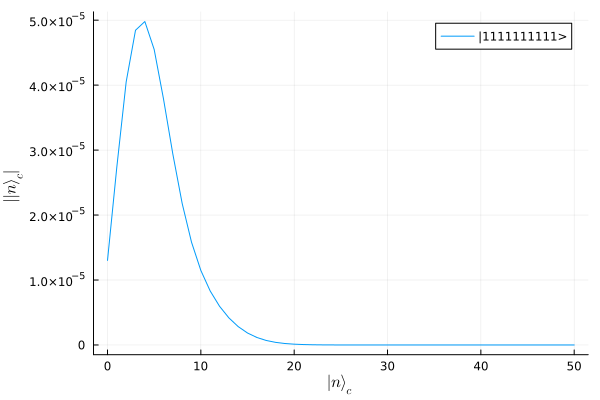

In [135]:
# Plot the cavity field as a function at a time for a spin state
function plot_cavity_field(sol, spin_state::Vector{Int}, p::DifferentialProblem, t::Float64; type=:both)
    N, n_max = p.N, p.n_max
    boson_states = collect(0:n_max)
    indexes = combined_indexes(boson_states, spin_state, p)
    ψ = sol(t)[indexes]
    if type == :real
        plot(boson_states, real.(ψ), label="Re|$(join(spin_state, ""))>")
        ylabel!(L"Re[|n\rangle_c]")
    elseif type == :imag
        plot(boson_states, imag.(ψ), label="Im|$(join(spin_state, ""))>")
        ylabel!(L"Im[|n\rangle_c]")
    elseif type == :both
        plot(boson_states, real.(ψ), label="Re|$(join(spin_state, ""))>")
        plot!(boson_states, imag.(ψ), label="Im|$(join(spin_state, ""))>")
        ylabel!(L"Re[|n\rangle_c], Im[|n\rangle_c]")
    elseif type == :abs
        plot(boson_states, abs.(ψ), label="|$(join(spin_state, ""))>")
        ylabel!(L"||n\rangle_c|")
    end
    # Add axis labels
    xlabel!(L"|n\rangle_c")
end
# Test 
plot_cavity_field(sol, n_excitation_vec(10, p), p, 3.0, type=:abs)

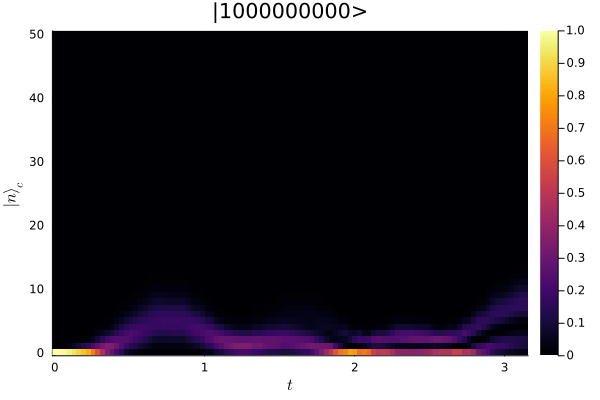

In [152]:
function n_timesteps(sol, minimum::Int=100, maximum::Int=1000)
    return min(max(minimum, length(sol.t)), maximum)
end
# Plot the time evolution of the cavity field for a spin state (heatmap)
function plot_cavity_field_in_time(sol, spin_state::Vector{Int}, p::DifferentialProblem; type=:abs)
    # currently only supports abs 
    N, n_max = p.N, p.n_max
    T = sol.t[end]
    n_t = n_timesteps(sol)
    boson_states = collect(0:n_max)
    indexes = combined_indexes(boson_states, spin_state, p)
    ψ_t = zeros(ComplexF64, n_t, n_max+1)
    t_s = range(0, T, length=n_t)
    for (i, t) in enumerate(t_s)
        ψ_t[i, :] = sol(t)[indexes]
    end
    weights_abs2 = abs2.(ψ_t)
    for i in 1:n_t
        sum_weights = sum(weights_abs2[i, :])
        if sum_weights > 1e-30
            weights_abs2[i, :] ./= sum_weights
        end
    end
    heatmap(t_s, 0:n_max, weights_abs2', xlabel=L"t", ylabel=L"|n\rangle_c", title="|$(join(spin_state, ""))>")
end
# Test 
plot_cavity_field_in_time(sol, n_excitation_vec(1, p), p)
    

In [125]:
# !!! a better script would just iterate over entries of sparse matrix and not use indexes, as most will be zero !!!
# A function hat calculates the cummulative probabilities of all spin states with a certain spin excitation number 
function cum_prob_by_spin_excitations(sol, spin_excitations::Int, p::DifferentialProblem)
    N, n_max = p.N, p.n_max
    T = sol.t[end]
    n_t = n_timesteps(sol)
    boson_states = collect(0:n_max)
    indexes_by_cavity::Vector{Vector{Int}} = Vector{Vector{Int}}()
    for i in 0:n_max
        push!(indexes_by_cavity, gen_spin_excitation_indexes(spin_excitations, i, p))
    end
    cummulative_probs::Array{Float64, 2} = zeros(Float64, n_t, n_max+1)
    t_s = range(0, T, length=n_t)
    for (i, t) in enumerate(t_s) 
        for j in 0:n_max
            cummulative_probs[i, j+1] = sum(abs2.(sol(t)[indexes_by_cavity[j+1]]))
        end
    end
    return cummulative_probs
end
function all_cum_probs_sum_cavity(sol, p::DifferentialProblem)
    N, n_max = p.N, p.n_max
    T = sol.t[end]
    n_t = n_timesteps(sol)
    all_cummulative_probs::Array{Float64, 2} = zeros(Float64, n_t, N+1)
    for i in 1:N+1
        all_cummulative_probs[:, i] = sum(cum_prob_by_spin_excitations(sol, i-1, p), dims=2)
    end
    return all_cummulative_probs
end

all_cum_probs_sum_cavity (generic function with 1 method)

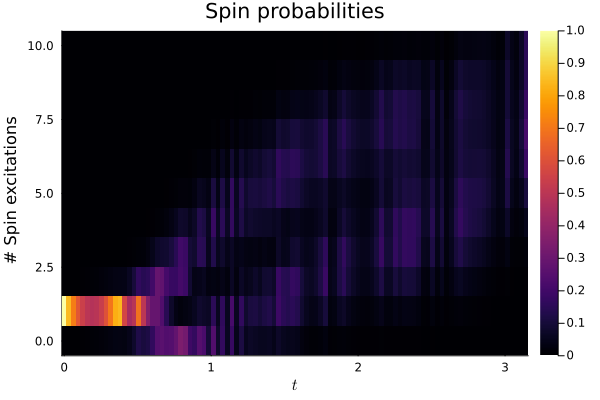

In [60]:
# Plot the spin probabilities
function plot_spin_probabilities(sol, p::DifferentialProblem)
    N, n_max = p.N, p.n_max
    T = sol.t[end]
    n_t = n_timesteps(sol)
    all_cummulative_probs = all_cum_probs_sum_cavity(sol, p)
    t_s = range(0, T, length=n_t)
    #plot heatmap 
    heatmap(t_s, 0:N, all_cummulative_probs', xlabel=L"t", ylabel=" # Spin excitations", title="Spin probabilities")
end
# Test 
plot_spin_probabilities(sol, p)

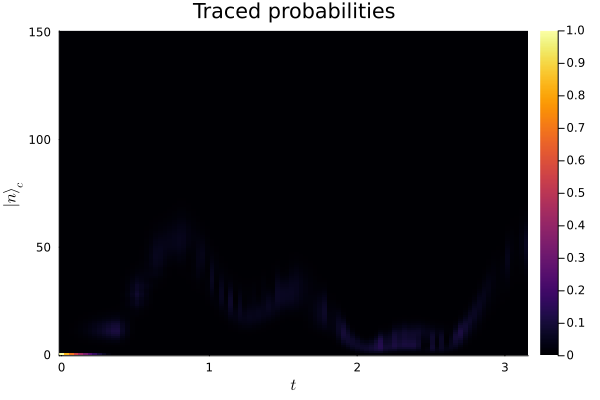

In [61]:
function all_cum_probs_by_cavity_excitations(sol, p::DifferentialProblem)
    N, n_max = p.N, p.n_max
    T = sol.t[end]
    n_t = n_timesteps(sol)
    indexes_by_spins::Vector{Vector{Int}} = [gen_cavity_excitation_indexes(cavity_excitations, p) for cavity_excitations in 0:n_max]
    cummulative_probs::Array{Float64, 2} = zeros(Float64, n_t, n_max+1)
    t_s = range(0, T, length=n_t)
    for (i, t) in enumerate(t_s)
        for j in 0:n_max
            cummulative_probs[i, j+1] = sum(abs2.(sol(t)[indexes_by_spins[j+1]]))
        end
    end
    return cummulative_probs
end

# Obviously wrong. find mistake
function plot_traced_cavity_probabilities(sol, p::DifferentialProblem)
    N, n_max = p.N, p.n_max
    T = sol.t[end]
    n_t = n_timesteps(sol)
    t_s = range(0, T, length=n_t)
    all_cummulative_probs = all_cum_probs_by_cavity_excitations(sol, p)
    # make heatmap 
    heatmap(t_s, 0:n_max, all_cummulative_probs', xlabel=L"t", ylabel=L"|n\rangle_c", title="Traced probabilities")
end
# Test 
plot_traced_cavity_probabilities(sol, p)

In [165]:
# Test out, generating an infinite sparse Vector with only one entry at 1024 
vec = sparsevec([1024], [1], 2^63-1)

9223372036854775807-element SparseVector{Int64, Int64} with 1 stored entry:
  [1024]  =  1